In [18]:
import importlib 
m = importlib.import_module(".model", "src")
from matplotlib import pyplot as plt
import numpy as np
import xgi

In [19]:
eta   = 0.5   # node retention in edges
gamma = 0.5   # poisson number of nodes from graph
beta  = 0.5   # poisson number of novel nodes

In [20]:
timesteps = int(2e4)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)

/tmp/ipykernel_159530/3644375509.py:4: RuntimeWarning: divide by zero encountered in divide
  v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)
/tmp/ipykernel_159530/3644375509.py:4: RuntimeWarning: invalid value encountered in divide
  v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)


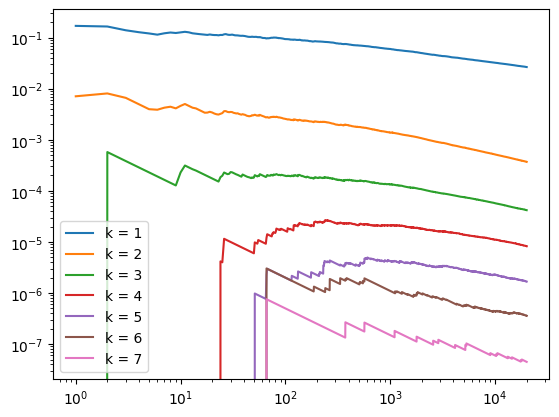

In [21]:
IX = xgi.linalg.hypergraph_matrix.intersection_profile(H.H).toarray()
np.fill_diagonal(IX, 0)
for k in range(1, IX.max()):
    v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)
    plt.plot(v, label = f"k = {k}")
    plt.loglog()
plt.legend()

# No Edge Selection 

This is a bit hacky at the moment, but does appear to convey the right idea: larger intersection sizes decay at faster rates (though is it $n^k$ rates?)

/tmp/ipykernel_159530/3767861386.py:18: RuntimeWarning: divide by zero encountered in divide
  v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)
/tmp/ipykernel_159530/3767861386.py:18: RuntimeWarning: invalid value encountered in divide
  v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)


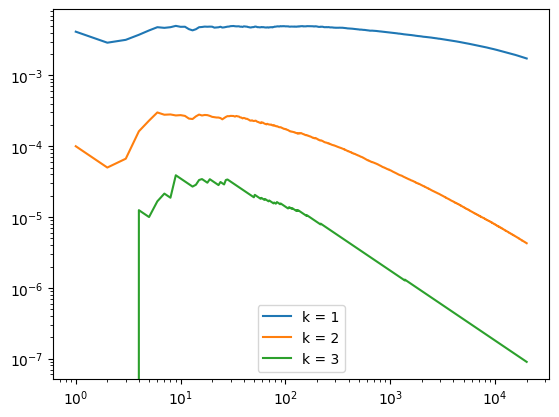

In [16]:
eta   = 0.0   # node retention in edges
gamma = 5     # poisson number of nodes from graph
beta  = 2     # poisson number of novel nodes

timesteps = int(2e4)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))
H.add_edge((4, 5))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, False)
    
IX = xgi.linalg.hypergraph_matrix.intersection_profile(H.H).toarray()
np.fill_diagonal(IX, 0)
for k in range(1, IX.max()):
    v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)
    plt.plot(v, label = f"k = {k}")
    plt.loglog()
plt.legend()